In [1]:
!pip install pandas

DEPRECATION: Loading egg at /opt/homebrew/lib/python3.11/site-packages/scapy-2.5.0.dev40-py3.11.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python3.11 -m pip install --upgrade pip


In [5]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np

In [7]:
df = pd.read_csv("data/raw/cust_support_ticket.csv")

In [8]:
df.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN


In [9]:
df.shape

(28587, 16)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28587 entries, 0 to 28586
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   subject   24749 non-null  object
 1   body      28587 non-null  object
 2   answer    28580 non-null  object
 3   type      28587 non-null  object
 4   queue     28587 non-null  object
 5   priority  28587 non-null  object
 6   language  28587 non-null  object
 7   version   28587 non-null  int64 
 8   tag_1     28587 non-null  object
 9   tag_2     28574 non-null  object
 10  tag_3     28451 non-null  object
 11  tag_4     25529 non-null  object
 12  tag_5     14545 non-null  object
 13  tag_6     5874 non-null   object
 14  tag_7     2040 non-null   object
 15  tag_8     565 non-null    object
dtypes: int64(1), object(15)
memory usage: 3.5+ MB


In [11]:
df.columns.tolist()

['subject',
 'body',
 'answer',
 'type',
 'queue',
 'priority',
 'language',
 'version',
 'tag_1',
 'tag_2',
 'tag_3',
 'tag_4',
 'tag_5',
 'tag_6',
 'tag_7',
 'tag_8']

In [12]:
df['language'].value_counts()

language
en    16338
de    12249
Name: count, dtype: int64

In [13]:
df = df[df['language'] == 'en'].reset_index(drop=True)
df

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
3,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN
4,Feature Query,"Dear Customer Support,\n\nI hope this message ...",Thank you for your inquiry. Please specify whi...,Request,Technical Support,high,en,51,Feature,Product,Documentation,Feedback,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16333,Problem with Billing Adjustment,An unexpected billing discrepancy has been not...,We apologize for the billing discrepancy in th...,Incident,Billing and Payments,high,en,400,Billing,Payment,Performance,Bug,NaN,NaN,NaN,NaN
16334,Urgent: Incident Involving Data Breach in Medi...,"A data breach has occurred, which might be rel...","Dear [Name], we acknowledge the urgency of the...",Problem,Product Support,medium,en,400,Security,Incident,Bug,Performance,NaN,NaN,NaN,NaN
16335,Performance Problem with Data Analytics Tool,The data analytics tool experiences sluggish p...,We are addressing the performance issue with t...,Incident,Technical Support,high,en,400,Performance,IT,Tech Support,NaN,NaN,NaN,NaN,NaN
16336,Update Request for SaaS Platform Integration F...,Requesting an update on the integration featur...,Received your request for updates on the integ...,Change,IT Support,high,en,400,Feature,IT,Tech Support,NaN,NaN,NaN,NaN,NaN


In [14]:
df = df[['body','subject','queue']].copy()
df = df.rename(columns={'queue': 'category'})
df.head()

,body,subject,category
0,"Dear Customer Support Team,\n\nI am writing to...",Account Disruption,Technical Support
1,"Dear Customer Support Team,\n\nI hope this mes...",Query About Smart Home System Integration Feat...,Returns and Exchanges
2,"Dear Customer Support Team,\n\nI hope this mes...",Inquiry Regarding Invoice Details,Billing and Payments
3,"Dear Support Team,\n\nI hope this message reac...",Question About Marketing Agency Software Compa...,Sales and Pre-Sales
4,"Dear Customer Support,\n\nI hope this message ...",Feature Query,Technical Support


In [15]:
print("Null values: ", df.isnull().sum())
print("\nUnique categories: ", df['category'].unique())
print("\nCategory counts: ", df['category'].value_counts())
print("\nDuplicate queries: ", df['body'].duplicated().sum())

Null values:  body           0
subject     2607
category       0
dtype: int64

Unique categories:  ['Technical Support' 'Returns and Exchanges' 'Billing and Payments'
 'Sales and Pre-Sales' 'Service Outages and Maintenance' 'Product Support'
 'IT Support' 'Customer Service' 'Human Resources' 'General Inquiry']

Category counts:  category
Technical Support                  4737
Product Support                    3073
Customer Service                   2410
IT Support                         1942
Billing and Payments               1595
Returns and Exchanges               820
Service Outages and Maintenance     664
Sales and Pre-Sales                 513
Human Resources                     348
General Inquiry                     236
Name: count, dtype: int64

Duplicate queries:  0


In [ ]:
# clean text
STRIP_PATTERNS = [
    r'dear\s+(customer\s+support(\s+team)?|support\s+team|support|team)[,\s]*',
    r'^(support\s+team|customer\s+support(\s+team)?)[,\s]*',
    r'i\s+hope\s+this\s+message\s+(reaches|finds)\s+you\s+(well|in\s+good\s+health)[.\s,]*',
    r'i\s+am\s+(writing|reaching\s+out|submitting\s+a\s+report)\s+to\s+',
    r'thank\s+you\s+(very\s+much\s+)?for\s+your\s+(assistance|help|support)[.\s]*',
    r'best\s+regards[,.\s]*',
    r'kind\s+regards[,.\s]*',
    r'yours\s+(sincerely|faithfully)[,.\s]*',
    r'i\s+look\s+forward\s+to\s+your\s+(prompt\s+)?repl(y|ies)[.\s]*',
]

def clean_text(text):
    if pd.isna(text):
        return ''
    text = str(text)
    text = text.replace("\\n", " ")
    text = text.replace("\n", " ")
    for pattern in STRIP_PATTERNS:
        text = re.sub(pattern, ' ', text, flags = re.IGNORECASE)
    text = re.sub(r'<[^>]+>', ' ', text)    # remove any HTML tags
    text = re.sub(r'\s+', ' ', text).strip()
    return text
    
df['body_clean'] = df['body'].apply(clean_text)
df['text'] = df['subject'] + ' - ' + df['body_clean'] #single classifier input

print(f"\nSample cleaned text:\n{df['text'].iloc[0]}")


Sample cleaned text:
Account Disruption - report a significant problem with the centralized account management portal, which currently appears to be offline. This outage is blocking access to account settings, leading to substantial inconvenience. I have attempted to log in multiple times using different browsers and devices, but the issue persists. Could you please provide an update on the outage status and an estimated time for resolution? Also, are there any alternative ways to access and manage my account during this downtime?


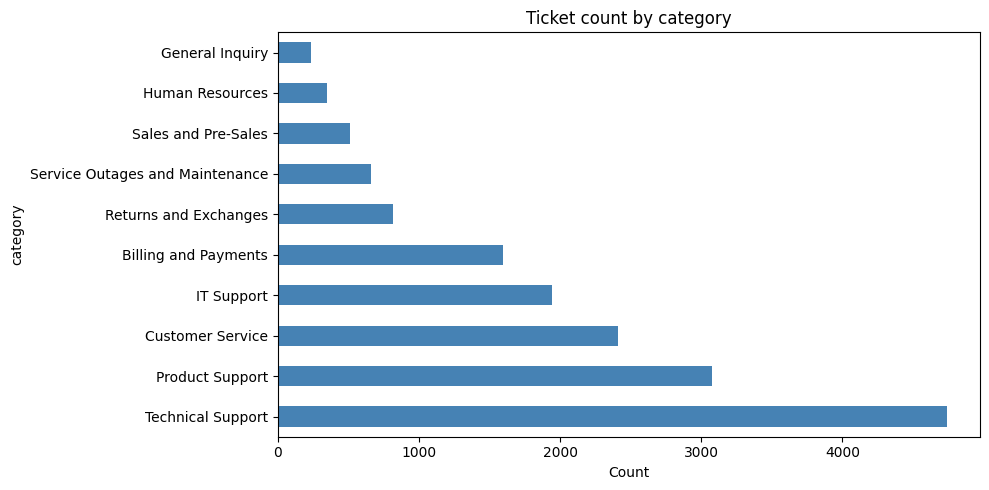

In [18]:
# Class distribution
plt.figure(figsize = (10, 5))
df['category'].value_counts().plot(kind = 'barh', color = 'steelblue')
plt.title('Ticket count by category')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

In [19]:
# The dataset is pretty imbalanced.
# Imbalance Analysis
from collections import Counter

counts = df['category'].value_counts()
props = df['category'].value_counts(normalize=True)

imbalance_df = pd.DataFrame({
    'count' : counts,
    'proportion' : props.round(4),
    'imbalance_ratio' : (counts.max() / counts).round(2)
})
print(imbalance_df)
print(f"\nOverall imbalance ratio (max/min): {counts.max() / counts.min():.2f}")


                                 count  proportion  imbalance_ratio
category                                                           
Technical Support                 4737      0.2899             1.00
Product Support                   3073      0.1881             1.54
Customer Service                  2410      0.1475             1.97
IT Support                        1942      0.1189             2.44
Billing and Payments              1595      0.0976             2.97
Returns and Exchanges              820      0.0502             5.78
Service Outages and Maintenance    664      0.0406             7.13
Sales and Pre-Sales                513      0.0314             9.23
Human Resources                    348      0.0213            13.61
General Inquiry                    236      0.0144            20.07

Overall imbalance ratio (max/min): 20.07


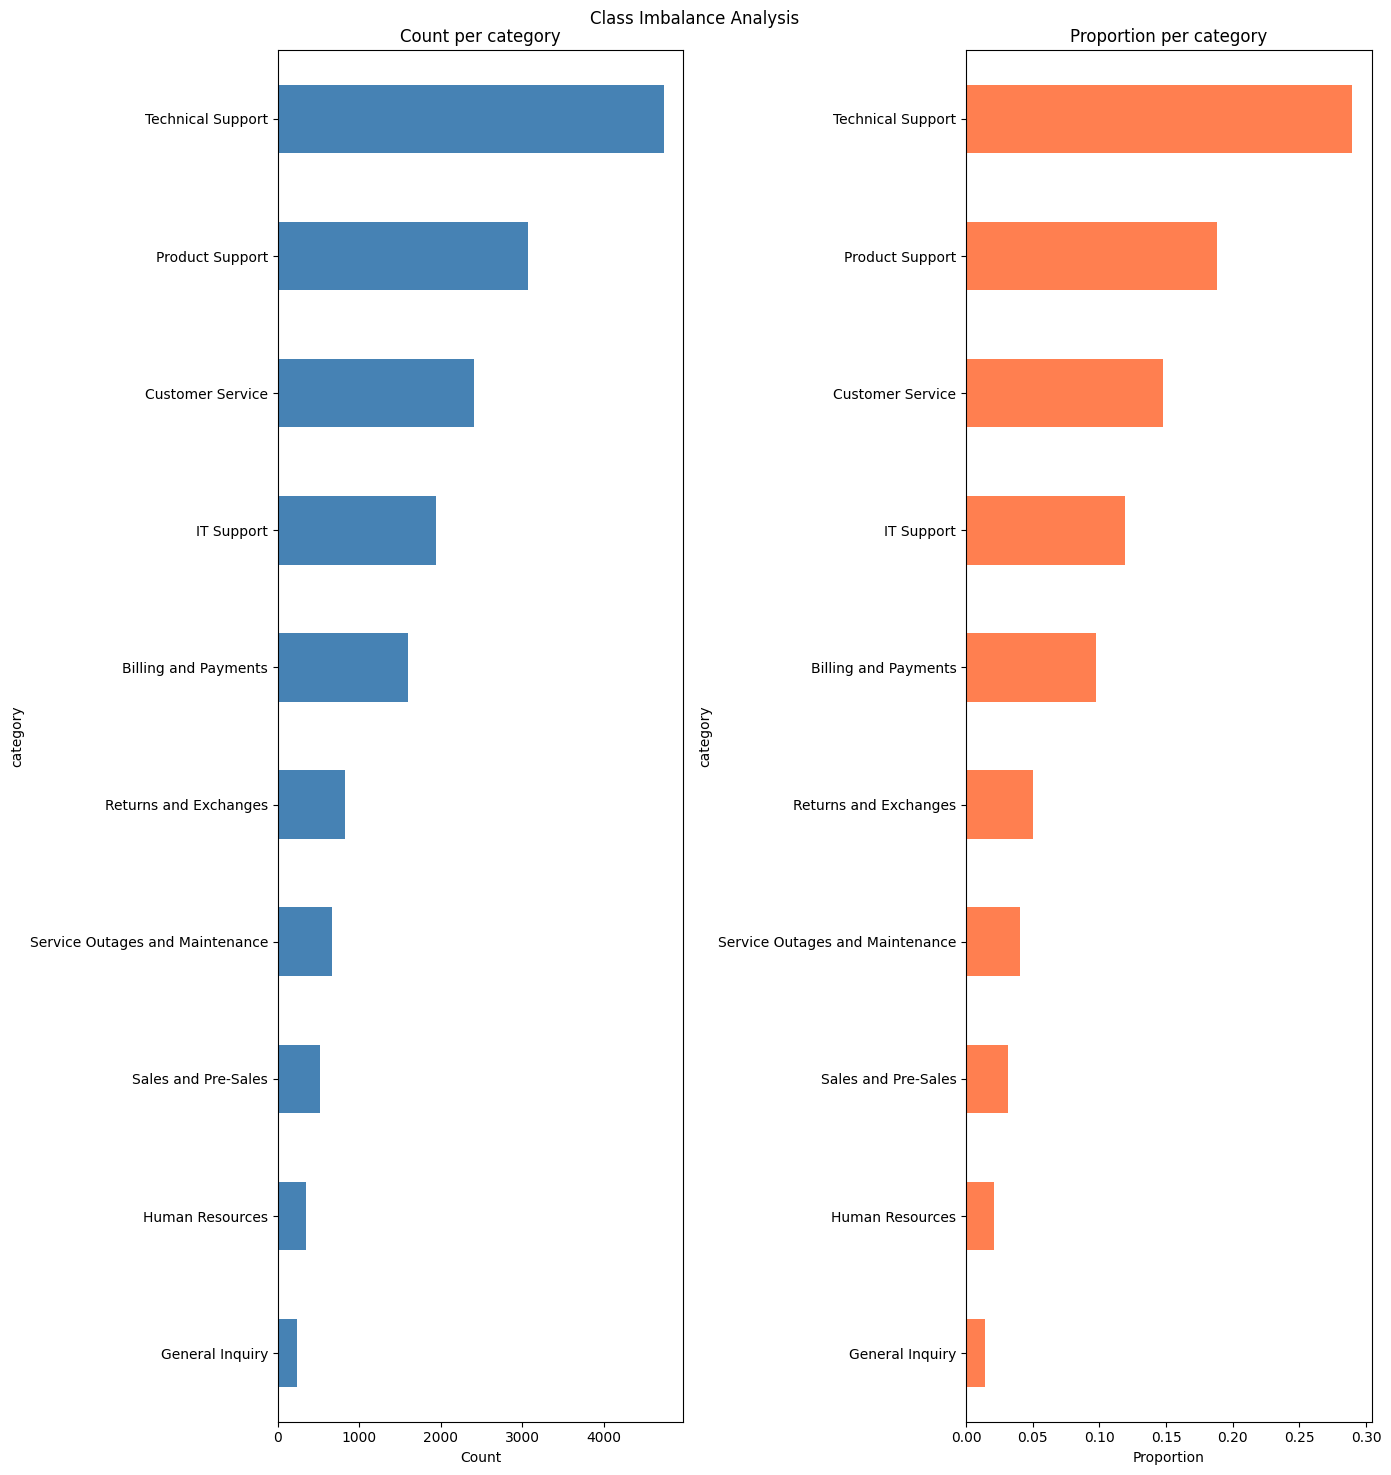

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 15))
imbalance_df['count'].sort_values().plot(kind = 'barh', ax=axes[0], color='steelblue')
axes[0].set_title('Count per category')
axes[0].set_xlabel('Count')

imbalance_df['proportion'].sort_values().plot(kind = 'barh', ax=axes[1], color='coral')
axes[1].set_title('Proportion per category')
axes[1].set_xlabel('Proportion')

plt.suptitle('Class Imbalance Analysis')
plt.tight_layout()
plt.show()

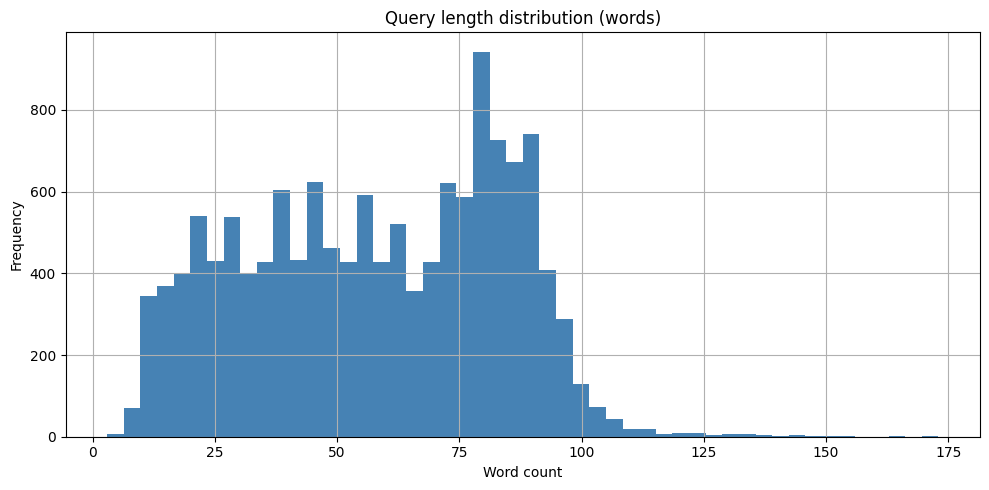

count    13731.000000
mean        57.767825
std         26.029262
min          3.000000
25%         36.000000
50%         59.000000
75%         81.000000
max        173.000000
Name: text_len, dtype: float64


In [21]:
# Text Length distribution
df['text_len'] = df['text'].str.split().str.len()
plt.figure(figsize = (10, 5))
df['text_len'].clip(upper = 300).hist(bins = 50, color = 'steelblue')
plt.title('Query length distribution (words)')
plt.xlabel('Word count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(df['text_len'].describe())

In [22]:
# Query length analysis
print("Min query length: ", min(df['text_len']))
print("Max query length: ", max(df['text_len']))

print("Queries < 10 words: ", (df['text_len']<10).sum())
print("Queries < 5 words: ", (df['text_len']<5).sum())

Min query length:  3.0
Max query length:  173.0
Queries < 10 words:  77
Queries < 5 words:  1


In [25]:
# Short queries content
print(df[df['text_len'] <= 5].head(10))

                                                    body  \
995                                    Assistance Needed   
14648  Thecompanyisincapableofaccessinginvestmentanal...   

                                         subject           category  \
995                            Issue Encountered  Technical Support   
14648  ConcernregardingSystemInvestmentAnalytics  Technical Support   

                                              body_clean  \
995                                    Assistance Needed   
14648  Thecompanyisincapableofaccessinginvestmentanal...   

                                                    text  text_len  
995                Issue Encountered - Assistance Needed       5.0  
14648  ConcernregardingSystemInvestmentAnalytics - Th...       3.0  


In [ ]:
# Query with len < 5 - because of improperly formatted content
# So dropping it
df = df[df['text_len'] > 5].reset_index(drop=True)

In [27]:
df.shape

(13729, 6)

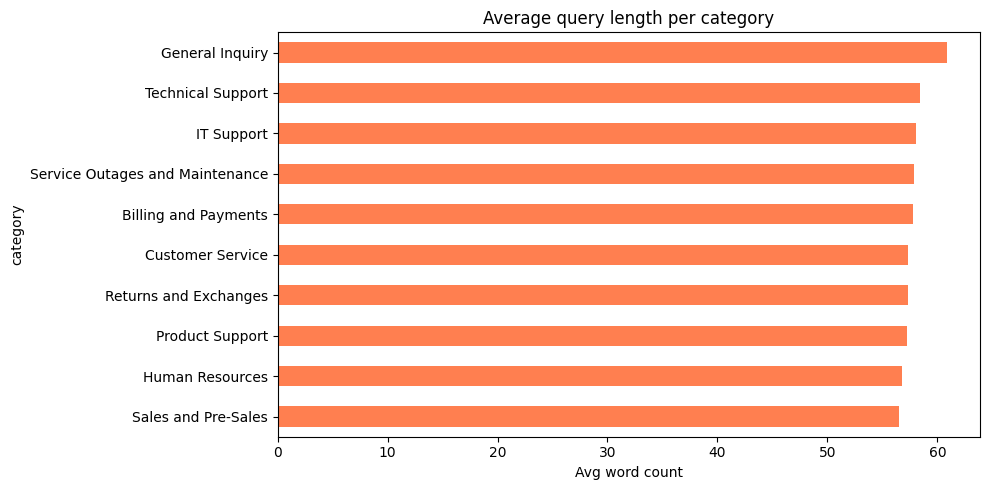

In [28]:
# Avg query length per category
plt.figure(figsize=(10, 5))
df.groupby('category')['text_len'].mean().sort_values().plot(
    kind='barh', color='coral'
)
plt.title('Average query length per category')
plt.xlabel('Avg word count')
plt.tight_layout()
plt.show()

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

def top_terms(texts, n=15):
    vec = TfidfVectorizer(max_features=5000, stop_words='english')
    vec.fit(texts)
    scores = np.asarray(vec.transform(texts).mean(axis=0)).flatten()
    top_idx = scores.argsort()[::-1][:n]
    terms = vec.get_feature_names_out()
    return [terms[i] for i in top_idx]

print("Top terms BEFORE cleaning:")
print(top_terms(df['body'].fillna('')))

print("\nTop terms AFTER cleaning:")
print(top_terms(df['text'].fillna('')))

Top terms BEFORE cleaning:
['data', 'issue', 'software', 'security', 'information', 'assistance', 'provide', 'support', 'analytics', 'investment', 'medical', 'appreciate', 'integration', 'issues', 'digital']

Top terms AFTER cleaning:
['data', 'security', 'issue', 'analytics', 'software', 'medical', 'digital', 'investment', 'integration', 'assistance', 'problem', 'marketing', 'information', 'project', 'tools']


In [ ]:
from sklearn.model_selection import train_test_split

X = df['text']
y = df['category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"\nTrain class distribution:\n{y_train.value_counts()}")


Train: 10983 | Test: 2746

Train class distribution:
category
Technical Support                  3175
Product Support                    2086
Customer Service                   1636
IT Support                         1287
Billing and Payments               1079
Returns and Exchanges               549
Service Outages and Maintenance     465
Sales and Pre-Sales                 328
Human Resources                     228
General Inquiry                     150
Name: count, dtype: int64


In [37]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report
import time

def run_experiment(name, pipeline, X_train, X_test, y_train, y_test):
    # cross validation on train dataset
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1
    )

    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"CV Macro F1 (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    # =========================
    # TRAIN ON FULL TRAIN DATA
    # =========================
    start = time.time()
    pipeline.fit(X_train, y_train)
    train_time = round(time.time() - start, 2)

    # =========================
    # TEST SET EVALUATION
    # =========================
    start = time.time()
    y_pred = pipeline.predict(X_test)
    inference_time = round((time.time() - start) * 1000 / len(X_test), 4)

    report = classification_report(y_test, y_pred, output_dict=True)
    macro_f1 = round(report['macro avg']['f1-score'], 4)
    accuracy  = round(report['accuracy'], 4)

    print(f"\nTest Accuracy: {accuracy}")
    print(f"Test Macro F1: {macro_f1}")
    print(f"Train time: {train_time}s")
    print(f"Inference time: {inference_time}ms/sample")
    print(classification_report(y_test, y_pred))

    return {
        'model': name,
        'cv_macro_f1_mean': round(cv_scores.mean(), 4),
        'cv_macro_f1_std': round(cv_scores.std(), 4),
        'test_accuracy': accuracy,
        'test_macro_f1': macro_f1,
        'train_time_s': train_time,
        'inference_ms': inference_time
    }

results = []

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# With TF-IDF
# --- Experiment 1: LR without class weights (baseline) ---
lr_baseline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2), max_features=20000,
        stop_words='english', sublinear_tf=True
    )),
    ('clf', LogisticRegression(max_iter=1000, C=1))
])
results.append(run_experiment(
    'LR — no balancing', lr_baseline,
    X_train, X_test, y_train, y_test
))


Model: LR — no balancing
CV Macro F1 (5-fold): 0.3479 ± 0.0128

Test Accuracy: 0.5324
Test Macro F1: 0.3676
Train time: 5.15s
Inference time: 0.0527ms/sample
                                 precision    recall  f1-score   support

           Billing and Payments       0.90      0.67      0.77       270
               Customer Service       0.46      0.50      0.48       409
                General Inquiry       0.00      0.00      0.00        37
                Human Resources       1.00      0.02      0.03        57
                     IT Support       0.64      0.22      0.33       322
                Product Support       0.50      0.50      0.50       522
          Returns and Exchanges       0.93      0.09      0.17       137
            Sales and Pre-Sales       1.00      0.07      0.14        82
Service Outages and Maintenance       0.87      0.51      0.64       116
              Technical Support       0.48      0.84      0.61       794

                       accuracy     

/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packag

In [39]:
print(results)

[{'model': 'LR — no balancing', 'cv_macro_f1_mean': 0.3479, 'cv_macro_f1_std': 0.0128, 'test_accuracy': 0.5324, 'test_macro_f1': 0.3676, 'train_time_s': 5.15, 'inference_ms': 0.0527}]


In [41]:
# --- Experiment 2: LR with class weights ---
lr_weighted = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2), max_features=20000,
        stop_words='english', sublinear_tf=True
    )),
    ('clf', LogisticRegression(
        max_iter=1000, C=1,
        class_weight='balanced'   # sklearn handles the weighting
    ))
])
results.append(run_experiment(
    'LR — class weighted', lr_weighted,
    X_train, X_test, y_train, y_test
))


Model: LR — class weighted
CV Macro F1 (5-fold): 0.4939 ± 0.0117

Test Accuracy: 0.5149
Test Macro F1: 0.5261
Train time: 4.48s
Inference time: 0.0532ms/sample
                                 precision    recall  f1-score   support

           Billing and Payments       0.77      0.71      0.74       270
               Customer Service       0.43      0.48      0.46       409
                General Inquiry       0.49      0.57      0.53        37
                Human Resources       0.44      0.65      0.52        57
                     IT Support       0.40      0.48      0.44       322
                Product Support       0.53      0.39      0.45       522
          Returns and Exchanges       0.42      0.51      0.46       137
            Sales and Pre-Sales       0.28      0.70      0.40        82
Service Outages and Maintenance       0.64      0.85      0.73       116
              Technical Support       0.62      0.48      0.54       794

                       accuracy   

In [43]:
# --- Experiment 3: RF with baseline ---
from sklearn.ensemble import RandomForestClassifier

rf_baseline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=20000,
        stop_words='english',
        sublinear_tf=True
    )),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

results.append(run_experiment(
    'RF — no balancing', rf_baseline,
    X_train, X_test, y_train, y_test
))


Model: RF — no balancing
CV Macro F1 (5-fold): 0.5553 ± 0.0080

Test Accuracy: 0.6482
Test Macro F1: 0.6058
Train time: 7.05s
Inference time: 0.1162ms/sample
                                 precision    recall  f1-score   support

           Billing and Payments       0.94      0.74      0.83       270
               Customer Service       0.58      0.62      0.60       409
                General Inquiry       0.86      0.32      0.47        37
                Human Resources       0.94      0.28      0.43        57
                     IT Support       0.94      0.39      0.55       322
                Product Support       0.71      0.54      0.62       522
          Returns and Exchanges       0.98      0.42      0.59       137
            Sales and Pre-Sales       1.00      0.37      0.54        82
Service Outages and Maintenance       0.90      0.65      0.75       116
              Technical Support       0.53      0.91      0.67       794

                       accuracy     

In [44]:
# --- Experiment 4: RF with baseline ---
rf_weighted = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=20000,
        stop_words='english',
        sublinear_tf=True
    )),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

results.append(run_experiment(
    'RF — class weighted', rf_weighted,
    X_train, X_test, y_train, y_test
))


Model: RF — class weighted
CV Macro F1 (5-fold): 0.5786 ± 0.0069

Test Accuracy: 0.6672
Test Macro F1: 0.6541
Train time: 10.07s
Inference time: 0.0887ms/sample
                                 precision    recall  f1-score   support

           Billing and Payments       0.93      0.76      0.83       270
               Customer Service       0.59      0.62      0.61       409
                General Inquiry       1.00      0.43      0.60        37
                Human Resources       0.96      0.40      0.57        57
                     IT Support       0.97      0.40      0.56       322
                Product Support       0.75      0.56      0.64       522
          Returns and Exchanges       0.97      0.47      0.64       137
            Sales and Pre-Sales       1.00      0.44      0.61        82
Service Outages and Maintenance       0.85      0.74      0.79       116
              Technical Support       0.55      0.92      0.68       794

                       accuracy  

In [58]:
!pip install xgboost

DEPRECATION: Loading egg at /opt/homebrew/lib/python3.11/site-packages/scapy-2.5.0.dev40-py3.11.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python3.11 -m pip install --upgrade pip


In [64]:
def run_xgb_experiment(name, model, X_train, X_test, y_train, y_test, le, sample_weights=None):
    
    start = time.time()
    if sample_weights is not None:
        model.fit(X_train, y_train, sample_weight=sample_weights)
    else:
        model.fit(X_train, y_train)
    train_time = round(time.time() - start, 2)

    start = time.time()
    y_pred = model.predict(X_test)
    inference_time = round((time.time() - start) * 1000 / X_test.shape[0], 4)

    y_pred_labels = le.inverse_transform(y_pred)
    y_true_labels = le.inverse_transform(y_test)

    report = classification_report(y_true_labels, y_pred_labels, output_dict=True)
    macro_f1 = round(report['macro avg']['f1-score'], 4)
    accuracy  = round(report['accuracy'], 4)

    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"Accuracy: {accuracy}")
    print(f"Macro F1: {macro_f1}")
    print(classification_report(y_true_labels, y_pred_labels))

    return {
        'model': name,
        'accuracy': accuracy,
        'macro_f1': macro_f1,
        'train_time_s': train_time,
        'inference_ms': inference_time
    }

In [65]:
# XGBoost setup
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder() 
y_train_enc = le.fit_transform(y_train) 
y_test_enc = le.transform(y_test) 

from scipy.sparse import issparse 

xgb_tfidf = TfidfVectorizer( ngram_range=(1, 2), max_features=30000, stop_words='english', sublinear_tf=True ) 
X_train_tfidf = xgb_tfidf.fit_transform(X_train) 
X_test_tfidf = xgb_tfidf.transform(X_test)

In [66]:
# --- Experiment 5: XGBoost with baseline ---
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

# name, pipeline, X_train, X_test, y_train, y_test

results.append(run_xgb_experiment(
    'XGBoost — baseline',
    xgb_model,
    X_train_tfidf,
    X_test_tfidf,
    y_train_enc,
    y_test_enc,
    le
))


Model: XGBoost — baseline
Accuracy: 0.4552
Macro F1: 0.3358
                                 precision    recall  f1-score   support

           Billing and Payments       0.93      0.64      0.76       270
               Customer Service       0.46      0.31      0.37       409
                General Inquiry       0.50      0.03      0.05        37
                Human Resources       1.00      0.09      0.16        57
                     IT Support       0.63      0.11      0.18       322
                Product Support       0.39      0.22      0.29       522
          Returns and Exchanges       0.67      0.07      0.13       137
            Sales and Pre-Sales       0.91      0.12      0.22        82
Service Outages and Maintenance       0.80      0.57      0.66       116
              Technical Support       0.39      0.89      0.54       794

                       accuracy                           0.46      2746
                      macro avg       0.67      0.31      0.3

In [71]:
# --- Experiment 6: XGBoost with sample weights ---
from sklearn.utils import compute_sample_weight

sample_weights = compute_sample_weight('balanced', y_train)

xgb_model_weighted = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

results.append(run_xgb_experiment(
    'XGBoost — sample weighted',
    xgb_model_weighted,
    X_train_tfidf,
    X_test_tfidf,
    y_train_enc,
    y_test_enc,
    le,
    sample_weights=sample_weights 
))


Model: XGBoost — sample weights
Accuracy: 0.4345
Macro F1: 0.4123
                                 precision    recall  f1-score   support

           Billing and Payments       0.81      0.70      0.75       270
               Customer Service       0.37      0.39      0.38       409
                General Inquiry       0.22      0.46      0.29        37
                Human Resources       0.27      0.40      0.32        57
                     IT Support       0.35      0.36      0.35       322
                Product Support       0.43      0.31      0.36       522
          Returns and Exchanges       0.31      0.34      0.32       137
            Sales and Pre-Sales       0.17      0.49      0.25        82
Service Outages and Maintenance       0.50      0.74      0.60       116
              Technical Support       0.55      0.45      0.49       794

                       accuracy                           0.43      2746
                      macro avg       0.40      0.46   

In [68]:
# --- Experiment 7: XGBoost with focal loss ---
import numpy as np

def softmax(x):
    e = np.exp(x - x.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

def focal_loss_obj(gamma=2.0):
    def obj(y_pred, dtrain):
        y_true = dtrain.get_label().astype(int)
        n = len(y_true)
        n_class = y_pred.shape[1]

        p = softmax(y_pred)

        y_oh = np.zeros_like(p)
        y_oh[np.arange(n), y_true] = 1.0

        p_t = p[np.arange(n), y_true]
        focal_w = (1 - p_t) ** gamma

        grad = focal_w[:, None] * (p - y_oh)
        hess = focal_w[:, None] * p * (1 - p)

        return grad.reshape(-1), hess.reshape(-1)

    return obj

In [73]:
import xgboost as xgb

dtrain = xgb.DMatrix(X_train_tfidf, label=y_train_enc)
dtest  = xgb.DMatrix(X_test_tfidf, label=y_test_enc)

# train with focal loss
params = {
    'objective': 'multi:softprob',
    'num_class': len(le.classes_),
    'max_depth': 4,
    'learning_rate': 0.1,
    'n_jobs': -1,
    'seed': 42
}

start = time.time()

model_focal = xgb.train(
    params,
    dtrain,
    num_boost_round=100,
    obj=focal_loss_obj(gamma=2.0),
    verbose_eval=False
)

train_time = round(time.time() - start, 2)

# prediction
raw_pred = model_focal.predict(dtest)
n_class = len(le.classes_)
raw_pred = raw_pred.reshape(-1, n_class)   # 🔥 reshape first
y_pred_enc = raw_pred.argmax(axis=1)
y_pred_fl = le.inverse_transform(y_pred_enc)

In [77]:
# ============================================================
# XGBOOST SETUP — REDUCED FEATURES FOR SPARSE MATRIX
# ============================================================

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils import compute_sample_weight
import xgboost as xgb
from xgboost import XGBClassifier
import numpy as np
import time

# Label encoding
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

# Separate TF-IDF for XGBoost — fewer features works better
# on sparse high-dimensional data
xgb_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10000,    # reduced from 30k
    stop_words='english',
    sublinear_tf=True
)
X_train_tfidf = xgb_tfidf.fit_transform(X_train)
X_test_tfidf  = xgb_tfidf.transform(X_test)

print(f"TF-IDF shape: {X_train_tfidf.shape}")

TF-IDF shape: (10983, 10000)


In [78]:
# ============================================================
# EXPERIMENT 5 — XGBOOST BASELINE (fixed config)
# ============================================================

xgb_baseline = XGBClassifier(
    n_estimators=300,        # was 100 — too few
    max_depth=6,             # was 4 — too shallow
    learning_rate=0.1,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    subsample=0.8,           # sample 80% of rows per tree
    colsample_bytree=0.3,    # sample 30% of features per tree
                             # critical for sparse TF-IDF
)

results.append(run_xgb_experiment(
    'XGBoost — baseline',
    xgb_baseline,
    X_train_tfidf,
    X_test_tfidf,
    y_train_enc,
    y_test_enc,
    le
))


Model: XGBoost — baseline
Accuracy: 0.5408
Macro F1: 0.4696
                                 precision    recall  f1-score   support

           Billing and Payments       0.88      0.71      0.79       270
               Customer Service       0.48      0.47      0.47       409
                General Inquiry       0.90      0.24      0.38        37
                Human Resources       0.90      0.16      0.27        57
                     IT Support       0.61      0.25      0.35       322
                Product Support       0.51      0.44      0.47       522
          Returns and Exchanges       0.76      0.19      0.30       137
            Sales and Pre-Sales       0.72      0.22      0.34        82
Service Outages and Maintenance       0.84      0.62      0.71       116
              Technical Support       0.48      0.83      0.61       794

                       accuracy                           0.54      2746
                      macro avg       0.71      0.41      0.4

In [79]:
# ============================================================
# EXPERIMENT 6 — XGBOOST SAMPLE WEIGHTED (fixed config)
# ============================================================

sample_weights = compute_sample_weight('balanced', y_train)

xgb_weighted = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    subsample=0.8,
    colsample_bytree=0.3,
)

results.append(run_xgb_experiment(
    'XGBoost — sample weighted',
    xgb_weighted,
    X_train_tfidf,
    X_test_tfidf,
    y_train_enc,
    y_test_enc,
    le,
    sample_weights=sample_weights
))


Model: XGBoost — sample weighted
Accuracy: 0.5524
Macro F1: 0.5479
                                 precision    recall  f1-score   support

           Billing and Payments       0.79      0.76      0.77       270
               Customer Service       0.45      0.54      0.49       409
                General Inquiry       0.70      0.38      0.49        37
                Human Resources       0.65      0.46      0.54        57
                     IT Support       0.48      0.52      0.50       322
                Product Support       0.49      0.48      0.48       522
          Returns and Exchanges       0.52      0.46      0.49       137
            Sales and Pre-Sales       0.38      0.50      0.43        82
Service Outages and Maintenance       0.69      0.72      0.70       116
              Technical Support       0.62      0.57      0.59       794

                       accuracy                           0.55      2746
                      macro avg       0.58      0.54  

In [83]:
# ============================================================
# EXPERIMENT 7 — XGBOOST FOCAL LOSS (fixed config)
# ============================================================

def softmax(x):
    e = np.exp(x - x.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

def focal_loss_obj(gamma=2.0):
    def obj(y_pred, dtrain):
        y_true  = dtrain.get_label().astype(int)
        n       = len(y_true)
        n_class = y_pred.shape[1]  # now shape is (n_samples, n_classes) in 2.1+

        p    = softmax(y_pred)
        y_oh = np.zeros_like(p)
        y_oh[np.arange(n), y_true] = 1.0

        p_t     = p[np.arange(n), y_true]
        focal_w = (1.0 - p_t) ** gamma

        grad = focal_w[:, None] * (p - y_oh)
        hess = focal_w[:, None] * p * (1.0 - p)

        # XGBoost 2.1+ expects (n_samples, n_classes) — no reshape needed
        return grad, hess

    return obj

# DMatrix for custom objective
dtrain = xgb.DMatrix(X_train_tfidf, label=y_train_enc)
dtest  = xgb.DMatrix(X_test_tfidf,  label=y_test_enc)

# Note: NO 'objective' key when using custom obj — they conflict
params = {
    'num_class'      : len(le.classes_),
    'max_depth'      : 6,
    'learning_rate'  : 0.1,
    'seed'           : 42,
    'subsample'      : 0.8,
    'colsample_bytree': 0.3,
    'nthread'        : -1,
}

start = time.time()
model_focal = xgb.train(
    params,
    dtrain,
    num_boost_round=300,         # increased from 100
    obj=focal_loss_obj(gamma=2.0),
    verbose_eval=50
)
train_time = round(time.time() - start, 2)
# ---------- clear this rowwwwww ------------
# Predict — no reshape needed in XGBoost 2.1+
raw_pred = model_focal.predict(dtest)   # returns raw scores, shape (n_samples,) or (n_samples * n_classes,)

print(f"raw_pred shape: {raw_pred.shape}")  # add this to see what you get
print(f"n_classes: {len(le.classes_)}")
# -------------------------------------------
# Get raw margin scores
raw_pred = model_focal.predict(dtest, output_margin=True)
print(f"raw_pred shape after output_margin: {raw_pred.shape}")

# If shape is (2746,) — it's flattened, reshape manually
n_samples = len(y_test)
n_classes = len(le.classes_)

if raw_pred.ndim == 1:
    raw_pred = raw_pred.reshape(n_samples, n_classes)

# Apply softmax to get probabilities
probs      = softmax(raw_pred)
y_pred_enc = probs.argmax(axis=1)
y_pred_fl  = le.inverse_transform(y_pred_enc)
y_pred_enc = raw_pred.argmax(axis=1)
y_pred_fl  = le.inverse_transform(y_pred_enc)

report = classification_report(y_test, y_pred_fl, output_dict=True)

print(f"\n{'='*50}")
print("Model: XGBoost — focal loss")
print(f"Accuracy : {round(report['accuracy'], 4)}")
print(f"Macro F1 : {round(report['macro avg']['f1-score'], 4)}")
print(classification_report(y_test, y_pred_fl))

results.append({
    'model'         : 'XGBoost — focal loss',
    'cv_macro_f1_mean': None,
    'cv_macro_f1_std' : None,
    'test_accuracy' : round(report['accuracy'], 4),
    'test_macro_f1' : round(report['macro avg']['f1-score'], 4),
    'train_time_s'  : train_time,
    'inference_ms'  : 0
})

raw_pred shape: (2746,)
n_classes: 10
raw_pred shape after output_margin: (2746, 10)

Model: XGBoost — focal loss
Accuracy : 0.547
Macro F1 : 0.4724
                                 precision    recall  f1-score   support

           Billing and Payments       0.90      0.71      0.79       270
               Customer Service       0.50      0.51      0.50       409
                General Inquiry       0.88      0.19      0.31        37
                Human Resources       0.56      0.18      0.27        57
                     IT Support       0.54      0.33      0.41       322
                Product Support       0.48      0.51      0.49       522
          Returns and Exchanges       0.62      0.20      0.31       137
            Sales and Pre-Sales       0.62      0.24      0.35        82
Service Outages and Maintenance       0.83      0.59      0.69       116
              Technical Support       0.51      0.75      0.61       794

                       accuracy               

In [84]:
# ============================================================
# ZERO SHOT — SENTENCE TRANSFORMERS
# ============================================================

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model_st = SentenceTransformer('all-MiniLM-L6-v2')
categories = sorted(df['category'].unique().tolist())

# Encode category names as reference vectors
cat_embeddings = model_st.encode(categories, show_progress_bar=False)

# Encode test queries
print("Encoding test queries...")
start = time.time()
query_embeddings = model_st.encode(
    X_test.tolist(),
    show_progress_bar=True,
    batch_size=64
)
inf_time = round((time.time() - start) * 1000 / len(X_test), 4)

# Predict by nearest category
sims       = cosine_similarity(query_embeddings, cat_embeddings)
y_pred_zs  = [categories[i] for i in sims.argmax(axis=1)]

report_zs  = classification_report(y_test, y_pred_zs, output_dict=True)

print(f"\n{'='*50}")
print("Model: Zero-Shot (MiniLM)")
print(f"Accuracy : {round(report_zs['accuracy'], 4)}")
print(f"Macro F1 : {round(report_zs['macro avg']['f1-score'], 4)}")
print(f"Inference: {inf_time}ms/sample")
print(classification_report(y_test, y_pred_zs))

results.append({
    'model'           : 'Zero-Shot (MiniLM)',
    'cv_macro_f1_mean': None,
    'cv_macro_f1_std' : None,
    'test_accuracy'   : round(report_zs['accuracy'], 4),
    'test_macro_f1'   : round(report_zs['macro avg']['f1-score'], 4),
    'train_time_s'    : 0,
    'inference_ms'    : inf_time
})

Encoding test queries...


Batches:   0%|          | 0/43 [00:00<?, ?it/s]


Model: Zero-Shot (MiniLM)
Accuracy : 0.2444
Macro F1 : 0.1914
Inference: 5.5507ms/sample
                                 precision    recall  f1-score   support

           Billing and Payments       0.90      0.58      0.70       270
               Customer Service       0.16      0.21      0.18       409
                General Inquiry       0.00      0.00      0.00        37
                Human Resources       0.16      0.07      0.10        57
                     IT Support       0.33      0.00      0.01       322
                Product Support       0.23      0.24      0.24       522
          Returns and Exchanges       0.16      0.09      0.12       137
            Sales and Pre-Sales       0.03      0.09      0.04        82
Service Outages and Maintenance       0.15      0.64      0.25       116
              Technical Support       0.31      0.26      0.28       794

                       accuracy                           0.24      2746
                      macro avg 

In [85]:
# ============================================================
# FINAL COMPARISON TABLE
# ============================================================

results_df = pd.DataFrame(results)
print("\n=== FULL RESULTS ===")
print(results_df[[
    'model', 'test_accuracy', 'test_macro_f1',
    'train_time_s', 'inference_ms'
]].to_string(index=False))

results_df.to_csv('week1_results.csv', index=False)


=== FULL RESULTS ===
                    model  test_accuracy  test_macro_f1  train_time_s  inference_ms
        LR — no balancing         0.5324         0.3676          5.15        0.0527
      LR — class weighted         0.6111         0.6239          5.72        0.0607
      LR — class weighted         0.5149         0.5261          4.48        0.0532
        RF — no balancing         0.6482         0.6058          7.05        0.1162
      RF — class weighted         0.6672         0.6541         10.07        0.0887
       XGBoost — baseline            NaN            NaN         43.29        0.0142
 XGBoost — sample weights            NaN            NaN         47.26        0.0148
       XGBoost — baseline            NaN            NaN         52.10        0.0143
 XGBoost — sample weights            NaN            NaN         50.47        0.0122
 XGBoost — sample weights            NaN            NaN         52.72        0.0157
     XGBoost — focal loss            NaN            Na

## Using embeddings

In [86]:
# ============================================================
# ENCODING — run once, reuse for all three models
# ============================================================

from sentence_transformers import SentenceTransformer
import time

embed_model = SentenceTransformer('all-MiniLM-L6-v2')

print("Encoding training queries...")
start = time.time()
X_train_emb = embed_model.encode(
    X_train.tolist(),
    batch_size=64,
    show_progress_bar=True
)
X_test_emb = embed_model.encode(
    X_test.tolist(),
    batch_size=64,
    show_progress_bar=True
)
encode_time = round(time.time() - start, 2)
print(f"Encoding done in {encode_time}s")
print(f"Embedding shape: {X_train_emb.shape}")  # expect (n_samples, 384)

Encoding training queries...


Batches:   0%|          | 0/172 [00:00<?, ?it/s]

Batches:   0%|          | 0/43 [00:00<?, ?it/s]

Encoding done in 88.02s
Embedding shape: (10983, 384)


In [87]:
# ============================================================
# EXPERIMENT 9 — EMBEDDING + LR (weighted)
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr_emb = LogisticRegression(
    max_iter=1000,
    C=5,
    class_weight='balanced'
)

start = time.time()
lr_emb.fit(X_train_emb, y_train)
train_time = round(time.time() - start, 2)

start = time.time()
y_pred_emb = lr_emb.predict(X_test_emb)
inf_time = round((time.time() - start) * 1000 / len(X_test), 4)

report = classification_report(y_test, y_pred_emb, output_dict=True)

print(f"\n{'='*50}")
print("Model: Embedding + LR (weighted)")
print(f"Accuracy : {round(report['accuracy'], 4)}")
print(f"Macro F1 : {round(report['macro avg']['f1-score'], 4)}")
print(f"Train time: {train_time}s | Inference: {inf_time}ms/sample")
print(classification_report(y_test, y_pred_emb))

results.append({
    'model'           : 'Embedding + LR (weighted)',
    'cv_macro_f1_mean': None,
    'cv_macro_f1_std' : None,
    'test_accuracy'   : round(report['accuracy'], 4),
    'test_macro_f1'   : round(report['macro avg']['f1-score'], 4),
    'train_time_s'    : train_time,
    'inference_ms'    : inf_time
})


Model: Embedding + LR (weighted)
Accuracy : 0.3165
Macro F1 : 0.3055
Train time: 3.94s | Inference: 0.0047ms/sample
                                 precision    recall  f1-score   support

           Billing and Payments       0.69      0.65      0.67       270
               Customer Service       0.30      0.22      0.25       409
                General Inquiry       0.07      0.46      0.13        37
                Human Resources       0.11      0.39      0.17        57
                     IT Support       0.28      0.32      0.30       322
                Product Support       0.32      0.16      0.21       522
          Returns and Exchanges       0.17      0.30      0.22       137
            Sales and Pre-Sales       0.14      0.49      0.21        82
Service Outages and Maintenance       0.42      0.76      0.54       116
              Technical Support       0.53      0.26      0.35       794

                       accuracy                           0.32      2746
     

In [88]:
# ============================================================
# EXPERIMENT 10 — EMBEDDING + RF (weighted)
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf_emb = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

start = time.time()
rf_emb.fit(X_train_emb, y_train)
train_time = round(time.time() - start, 2)

start = time.time()
y_pred_rf_emb = rf_emb.predict(X_test_emb)
inf_time = round((time.time() - start) * 1000 / len(X_test), 4)

report = classification_report(y_test, y_pred_rf_emb, output_dict=True)

print(f"\n{'='*50}")
print("Model: Embedding + RF (weighted)")
print(f"Accuracy : {round(report['accuracy'], 4)}")
print(f"Macro F1 : {round(report['macro avg']['f1-score'], 4)}")
print(f"Train time: {train_time}s | Inference: {inf_time}ms/sample")
print(classification_report(y_test, y_pred_rf_emb))

results.append({
    'model'           : 'Embedding + RF (weighted)',
    'cv_macro_f1_mean': None,
    'cv_macro_f1_std' : None,
    'test_accuracy'   : round(report['accuracy'], 4),
    'test_macro_f1'   : round(report['macro avg']['f1-score'], 4),
    'train_time_s'    : train_time,
    'inference_ms'    : inf_time
})


Model: Embedding + RF (weighted)
Accuracy : 0.6122
Macro F1 : 0.5209
Train time: 18.19s | Inference: 0.2021ms/sample
                                 precision    recall  f1-score   support

           Billing and Payments       0.97      0.70      0.81       270
               Customer Service       0.58      0.54      0.56       409
                General Inquiry       1.00      0.14      0.24        37
                Human Resources       1.00      0.16      0.27        57
                     IT Support       0.98      0.36      0.53       322
                Product Support       0.66      0.56      0.61       522
          Returns and Exchanges       1.00      0.32      0.49       137
            Sales and Pre-Sales       1.00      0.28      0.44        82
Service Outages and Maintenance       0.83      0.50      0.62       116
              Technical Support       0.50      0.91      0.64       794

                       accuracy                           0.61      2746
    

In [89]:
# ============================================================
# EXPERIMENT 11 — EMBEDDING + XGBOOST (weighted)
# ============================================================

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import compute_sample_weight

# Need encoded labels for XGBoost
le_emb = LabelEncoder()
y_train_enc_emb = le_emb.fit_transform(y_train)
y_test_enc_emb  = le_emb.transform(y_test)

sample_weights_emb = compute_sample_weight('balanced', y_train)

xgb_emb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    subsample=0.8,
    colsample_bytree=0.8,   # embeddings are dense — use more features
                             # unlike TF-IDF which needed 0.3
)

start = time.time()
xgb_emb.fit(
    X_train_emb, y_train_enc_emb,
    sample_weight=sample_weights_emb
)
train_time = round(time.time() - start, 2)

start = time.time()
y_pred_enc_emb = xgb_emb.predict(X_test_emb)
inf_time = round((time.time() - start) * 1000 / len(X_test), 4)

y_pred_xgb_emb = le_emb.inverse_transform(y_pred_enc_emb)
report = classification_report(y_test, y_pred_xgb_emb, output_dict=True)

print(f"\n{'='*50}")
print("Model: Embedding + XGBoost (weighted)")
print(f"Accuracy : {round(report['accuracy'], 4)}")
print(f"Macro F1 : {round(report['macro avg']['f1-score'], 4)}")
print(f"Train time: {train_time}s | Inference: {inf_time}ms/sample")
print(classification_report(y_test, y_pred_xgb_emb))

results.append({
    'model'           : 'Embedding + XGBoost (weighted)',
    'cv_macro_f1_mean': None,
    'cv_macro_f1_std' : None,
    'test_accuracy'   : round(report['accuracy'], 4),
    'test_macro_f1'   : round(report['macro avg']['f1-score'], 4),
    'train_time_s'    : train_time,
    'inference_ms'    : inf_time
})


Model: Embedding + XGBoost (weighted)
Accuracy : 0.6548
Macro F1 : 0.6242
Train time: 91.35s | Inference: 0.0155ms/sample
                                 precision    recall  f1-score   support

           Billing and Payments       0.95      0.73      0.82       270
               Customer Service       0.54      0.65      0.59       409
                General Inquiry       0.85      0.30      0.44        37
                Human Resources       1.00      0.39      0.56        57
                     IT Support       0.74      0.52      0.61       322
                Product Support       0.59      0.61      0.60       522
          Returns and Exchanges       0.85      0.44      0.58       137
            Sales and Pre-Sales       0.90      0.45      0.60        82
Service Outages and Maintenance       0.83      0.67      0.74       116
              Technical Support       0.62      0.81      0.70       794

                       accuracy                           0.65      2746

In [91]:
# ============================================================
# FINAL CLEAN TABLE — all experiments
# ============================================================

import pandas as pd

results_df = pd.DataFrame(results)
results_df = results_df.dropna(subset=['test_macro_f1'])
results_df = results_df.drop_duplicates(subset=['model'], keep='last')
results_df = results_df.reset_index(drop=True)

# Sort by Macro F1
results_df = results_df.sort_values('test_macro_f1', ascending=False)

print("\n=== FINAL RESULTS (sorted by Macro F1) ===")
print(results_df[[
    'model', 'test_accuracy', 'test_macro_f1',
    'train_time_s', 'inference_ms'
]].to_string(index=False))


=== FINAL RESULTS (sorted by Macro F1) ===
                         model  test_accuracy  test_macro_f1  train_time_s  inference_ms
           RF — class weighted         0.6672         0.6541         10.07        0.0887
Embedding + XGBoost (weighted)         0.6548         0.6242         91.35        0.0155
             RF — no balancing         0.6482         0.6058          7.05        0.1162
           LR — class weighted         0.5149         0.5261          4.48        0.0532
     Embedding + RF (weighted)         0.6122         0.5209         18.19        0.2021
          XGBoost — focal loss         0.5470         0.4724         90.41        0.0000
             LR — no balancing         0.5324         0.3676          5.15        0.0527
     Embedding + LR (weighted)         0.3165         0.3055          3.94        0.0047
            Zero-Shot (MiniLM)         0.2444         0.1914          0.00        5.5507
